<table><tr><th><div style='padding:15px;color:#030aa7;font-size:240%;text-align:center;font-weight:bold;font-family:Georgia,serif'>Utiliser des formes spécialisées — Météo</div></th></tr></table>
<table><tr><th><div style='padding:15px;color:#e50000;font-size:240%;text-align:center;font-style:italic;font-weight:bold;font-family:Georgia,serif'>Le besoin impose-t-il une forme particulière ?</div></th></tr></table>

<div style='text-align:center'><img src='https://raw.githubusercontent.com/rbizoi/dockerBigDataBI/refs/heads/master/images/bi/famille_8.png' width='1024'></div>
<div style='text-align:center'><img src='https://raw.githubusercontent.com/rbizoi/dockerBigDataBI/refs/heads/master/images/bi/famille_8_description.png' width='1024'></div>

<div style='padding:15px;color:#030aa7;font-family:Georgia,serif'>Atelier BI · Famille 08 · 6 graphiques × 3 bibliothèques</div>

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Introduction</div></b>

Lecture de l’année 2024 uniquement, modifiable par ANNEE. Aucun dictionnaire d’unités n’est fourni : les valeurs sont compatibles avec °C, %, m/s et hPa, mais les axes conservent « unité source ». Les plages de contrôle sont des hypothèses exploratoires explicites, à valider avec le producteur. Les hors-plage sont masquées par variable et comptées, sans supprimer toute la ligne. Une moyenne entre stations n’est pas une moyenne climatique territoriale.

**Objectif :** construire les six représentations de cette famille sur les données réelles, comparer les encodages et interpréter leurs limites. Les trois variantes utilisent exactement la même table préparée. Les constructions composites Seaborn sont signalées : cette bibliothèque ne propose pas tous les types nativement.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Sommaire</div></b>

1. Radar
2. Marimekko ou mosaïque
3. Gaufre ou waffle
4. Pyramide ou barres dos à dos
5. Nuage de points reliés
6. Aires empilées à 100 %

Exécution : ouvrir le dossier extrait, sélectionner un noyau Python avec les dépendances de `requirements.txt`, puis **Redémarrer le noyau et tout exécuter**. Les résultats sont déjà enregistrés. Adapter `config_donnees.json` si les fichiers changent de place.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Import des bibliothèques</div></b>

In [1]:
NOM_PROJET = '08_meteo'
from pathlib import Path
import os, json, warnings
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle, Polygon, Wedge
from matplotlib.collections import PatchCollection
from matplotlib.colors import Normalize
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from scipy.stats import gaussian_kde
import networkx as nx
import squarify

get_ipython().run_line_magic('matplotlib', 'inline')
SEED = 42
palette = ["#030aa7", "#e50000", "#d8863b", "#005f6a", "#6b7c85", "#751973",
           "#0485d1", "#ff7855", "#fbeeac", "#0cb577", "#95a3a6", "#c071fe"]
sns.set_theme(style='darkgrid', palette=palette, context='notebook', font_scale=1.05)
plt.rcParams.update({'figure.figsize': (11, 5), 'figure.dpi': 110})
pio.templates['bi_modele'] = pio.templates['plotly_white']
pio.templates['bi_modele'].layout.colorway = palette
pio.templates.default = 'bi_modele'
pio.renderers.default = 'plotly_mimetype'
px.defaults.color_discrete_sequence = palette
EXPORTER = False  # True : PNG statiques et HTML interactifs dans repertoire.images.
repertoireImages = Path('repertoire.images') / NOM_PROJET

def sauvegarderImage(nom, fig=None):
    fig = fig if fig is not None else plt.gcf()
    if EXPORTER:
        repertoireImages.mkdir(parents=True, exist_ok=True)
        fig.savefig(repertoireImages / (nom + '.png'), dpi=180, bbox_inches='tight')

def terminer(ax, titre, xlabel=None, ylabel=None):
    ax.set_title(titre, loc='left', fontweight='bold', pad=14)
    if xlabel is not None: ax.set_xlabel(xlabel)
    if ylabel is not None: ax.set_ylabel(ylabel)
    ax.figure.tight_layout()
    sauvegarderImage(ID_GRAPHIQUE + '_' + BIBLIOTHEQUE, ax.figure)
    plt.show()
    plt.close(ax.figure)

def montrer_plotly(fig, titre):
    fig.update_layout(title=titre, width=1000, height=520,
                      margin=dict(l=70, r=45, t=90, b=75),
                      font=dict(family='Arial', size=13))
    if EXPORTER:
        repertoireImages.mkdir(parents=True, exist_ok=True)
        fig.write_html(repertoireImages / (ID_GRAPHIQUE + '_plotly.html'), include_plotlyjs=True)
    fig.show()

def creer_axes(seaborn=False, **kwargs):
    # Matplotlib reste autonome ; Seaborn garde le style et la palette du modèle.
    plt.style.use('default')
    if seaborn: sns.set_theme(style='darkgrid', palette=palette, context='notebook')
    return plt.subplots(figsize=(11, 5), **kwargs)

print('Versions :', 'pandas', pd.__version__, 'seaborn', sns.__version__,
      'plotly', __import__('plotly').__version__, 'matplotlib', __import__('matplotlib').__version__)

Versions : pandas 2.3.3 seaborn 0.13.2 plotly 7.1.0 matplotlib 3.10.9


## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Outils du document</div></b>

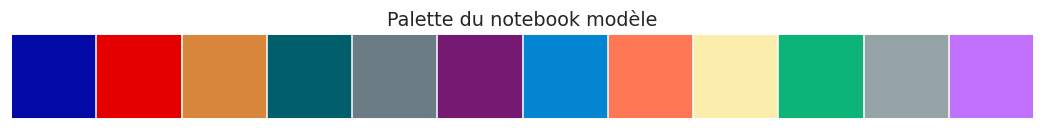

In [2]:
sns.palplot(sns.color_palette(palette))
plt.title('Palette du notebook modèle')
plt.show()
plt.close('all')

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Lecture des données</div></b>

<table><tr><th style="background:#053061;color:white">Colonne</th><th style="background:#053061;color:white">Description</th></tr><tr><td>Station</td><td>Identifiant de station conservé en texte</td></tr><tr><td>DateHeure</td><td>Date de mesure sans fuseau documenté</td></tr><tr><td>Temperature / Humidite</td><td>Température et humidité dans les unités du fichier</td></tr><tr><td>VitesseVent / Pression</td><td>Mesures dans les unités du fichier</td></tr><tr><td>regime</td><td>Classe dérivée : température <10, de 10 à <20, ou ≥20</td></tr></table>

In [3]:
CHEMINS = {'meteo': '/opt/spark/data/meteo.gzip', 'web': '/opt/spark/data/Web.Server.Access10.gzip', 'ecommerce': '/opt/spark/notebooks/ecommerce'}
configuration = Path('config_donnees.json')
if configuration.exists():
    CHEMINS.update(json.loads(configuration.read_text(encoding='utf-8')))
for cle in CHEMINS:
    CHEMINS[cle] = os.environ.get('BI_' + cle.upper(), CHEMINS[cle])
assert Path(CHEMINS['meteo']).exists(), 'Vérifier config_donnees.json'

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Contrôle des données et préparation</div></b>

In [4]:
ANNEE = 2024
colonnes = ['Station', 'DateHeure', 'Temperature', 'Humidite', 'VitesseVent', 'Pression']
brut = pd.read_parquet(CHEMINS['meteo'],
                       filters=[('Annee', '==', ANNEE)]).reset_index().rename(columns={'Nom':'Station'})[colonnes]
donnees = brut.copy()
donnees['DateHeure'] = pd.to_datetime(donnees['DateHeure'], errors='coerce')
donnees = donnees.dropna(subset=['Station', 'DateHeure'])
print('Lignes source sur l’année :', len(brut), '; dates/stations absentes :', len(brut)-len(donnees))
print('Doublons station/date conservés et signalés :', donnees.duplicated(['Station','DateHeure']).sum())
# Pas de suppression automatique des doublons : plusieurs mesures peuvent être légitimes.
regles = {'Temperature': (-90, 60), 'Humidite': (0, 100), 'VitesseVent': (0, 150), 'Pression': (500, 1100)}
audit = []
for col, (bas, haut) in regles.items():
    donnees[col] = pd.to_numeric(donnees[col], errors='coerce')
    hors = donnees[col].notna() & ~donnees[col].between(bas, haut)
    audit.append([col, int(donnees[col].isna().sum()), int(hors.sum())])
    donnees.loc[hors, col] = np.nan
display(pd.DataFrame(audit, columns=['Variable','Absentes','Hors plage masquées']))
donnees['mois'] = donnees['DateHeure'].dt.month
donnees['jour'] = donnees['DateHeure'].dt.floor('D')
# Classes pédagogiques dans l’unité de température du fichier.
donnees['regime'] = pd.cut(donnees['Temperature'], [-np.inf,10,20,np.inf],
                           labels=['< 10', '10 à < 20', '≥ 20'], right=False)
stations = donnees.groupby('Station')['Temperature'].count().nlargest(6).index.tolist()
assert len(stations) >= 3
station = stations[0]
print('Année :', ANNEE, '; station principale :', station, '; stations retenues :', stations)
display(donnees.select_dtypes('number').describe().T)

Lignes source sur l’année : 122295 ; dates/stations absentes : 0
Doublons station/date conservés et signalés : 0


,Variable,Absentes,Hors plage masquées
0,Temperature,3042,0
1,Humidite,3346,0
2,VitesseVent,143,0
3,Pression,3432,0


Année : 2024 ; station principale : Alencon ; stations retenues : ['Alencon', 'Bale', 'Le Puy', 'Lille', 'Lyon', 'Nancy']


,count,mean,std,min,25%,50%,75%,max
Temperature,119253.0,13.311918,6.834883,-12.1,8.8,13.0,17.7,38.7
Humidite,118949.0,78.363618,16.311435,1.0,68.0,82.0,92.0,100.0
VitesseVent,122152.0,3.754066,2.591127,0.0,1.9,3.1,5.0,27.0
Pression,118863.0,995.395800,25.643462,888.5,985.9,1002.7,1012.2,1037.7
mois,122295.0,6.515181,3.452406,1.0,4.0,7.0,10.0,12.0


# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Statistiques descriptives et analyse de données</div></b>

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>1 — Radar</div></b>

Comparer les profils médians de trois stations sur température, humidité, vent et pression. Variables : 4Q + station C. Normalisation min–max des médianes calculée sur toutes les stations ; le polygone ne mesure pas une performance.

In [5]:
variables=['Temperature','Humidite','VitesseVent','Pression']
med=donnees.groupby('Station')[variables].median().dropna()
profils=(med-med.min())/(med.max()-med.min()).replace(0,1)
retenues=[s for s in stations if s in profils.index][:3]
a=profils.loc[retenues]
angles=np.linspace(0,2*np.pi,len(variables),endpoint=False);angles_fermes=np.r_[angles,angles[0]]
display(med.loc[retenues]);display(a)

,Temperature,Humidite,VitesseVent,Pression
Station,,,,
Alencon,11.6,87.0,3.0,999.4
Bale,11.8,85.0,2.4,984.6
Le Puy,9.8,81.0,2.0,922.0


,Temperature,Humidite,VitesseVent,Pression
Station,,,,
Alencon,0.260870,0.892857,0.282609,0.839069
Bale,0.289855,0.821429,0.152174,0.689271
Le Puy,0.000000,0.678571,0.065217,0.055668


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

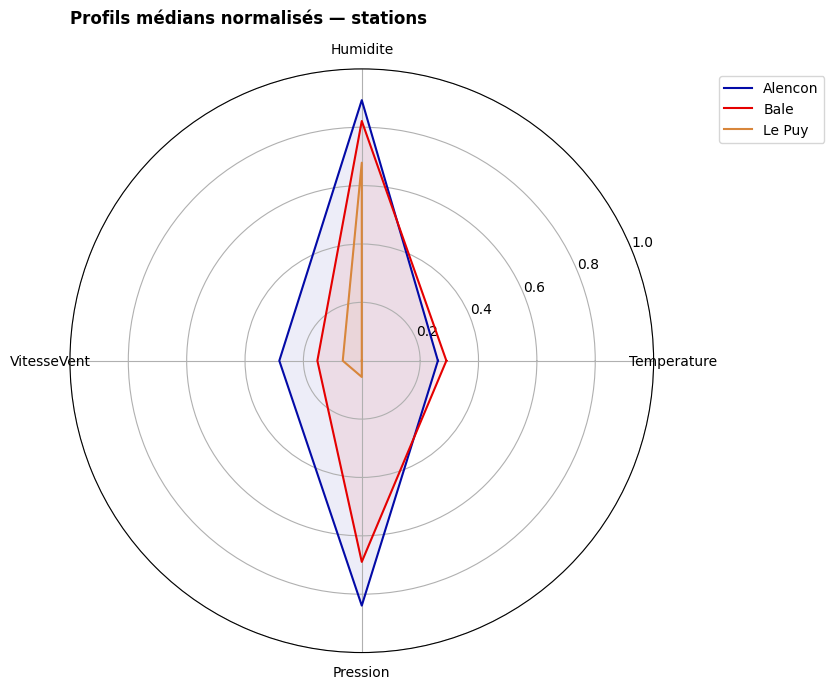

In [6]:
ID_GRAPHIQUE = '08_01'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=plt.subplots(figsize=(8,7),subplot_kw={'projection':'polar'})
for j,(s,r) in enumerate(a.iterrows()):ax.plot(angles_fermes,np.r_[r,r.iloc[0]],label=s,color=palette[j]);ax.fill(angles_fermes,np.r_[r,r.iloc[0]],alpha=.07,color=palette[j])
ax.set_xticks(angles,variables);ax.set_ylim(0,1);ax.legend(loc='upper left',bbox_to_anchor=(1.1,1))
terminer(ax,'Profils médians normalisés — stations')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn — composition avec Matplotlib</div></b>

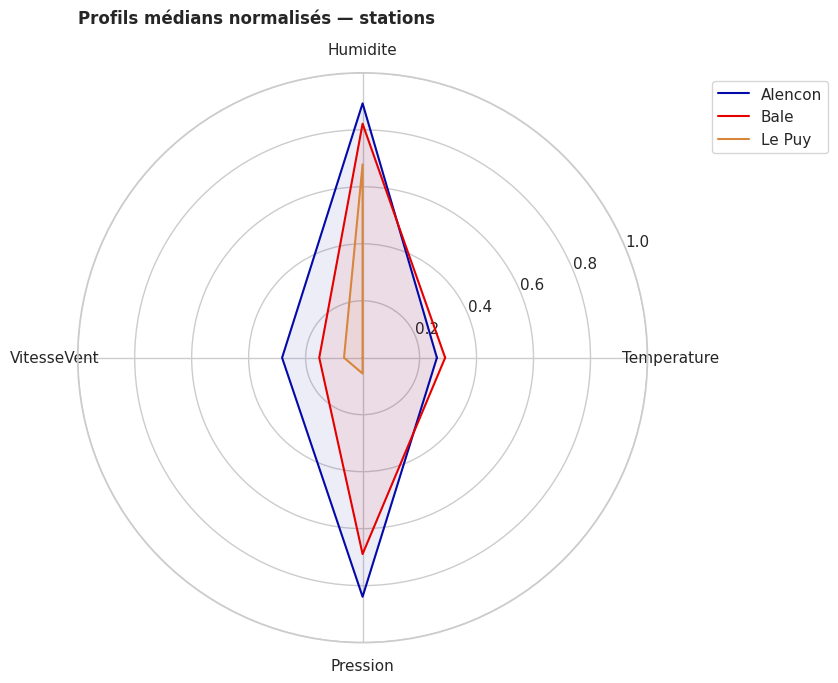

In [7]:
ID_GRAPHIQUE = '08_01'
BIBLIOTHEQUE = 'seaborn'
sns.set_theme(style='whitegrid',palette=palette)
fig,ax=plt.subplots(figsize=(8,7),subplot_kw={'projection':'polar'})
for j,(s,r) in enumerate(a.iterrows()):
    sns.lineplot(x=angles_fermes,y=np.r_[r,r.iloc[0]],estimator=None,sort=False,color=palette[j],label=s,ax=ax);ax.fill(angles_fermes,np.r_[r,r.iloc[0]],alpha=.07,color=palette[j])
ax.set_xticks(angles,variables);ax.set_ylim(0,1);ax.legend(loc='upper left',bbox_to_anchor=(1.1,1))
terminer(ax,'Profils médians normalisés — stations')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

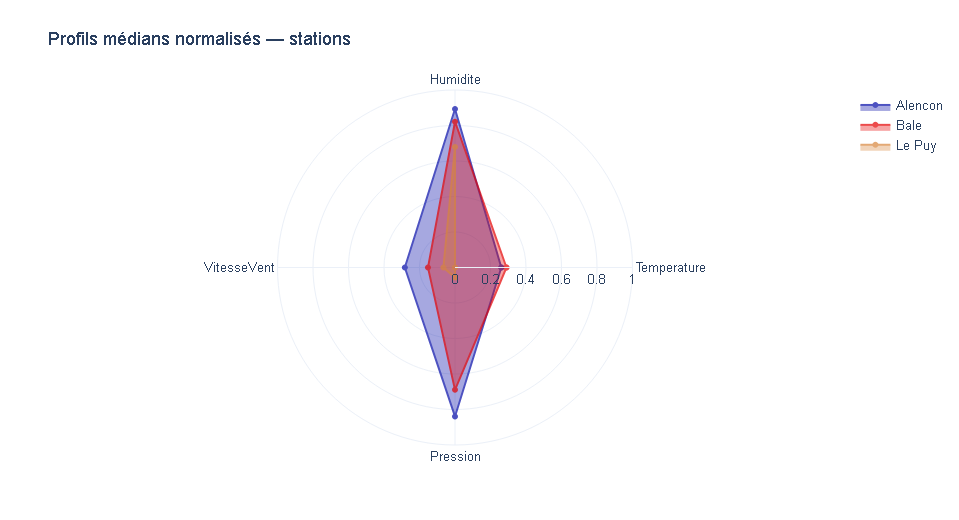

In [8]:
ID_GRAPHIQUE = '08_01'
BIBLIOTHEQUE = 'plotly'
fig=go.Figure()
for j,(s,r) in enumerate(a.iterrows()):fig.add_trace(go.Scatterpolar(r=np.r_[r,r.iloc[0]],theta=variables+[variables[0]],fill='toself',name=s,line_color=palette[j],opacity=.7))
fig.update_layout(polar={'radialaxis':{'range':[0,1]}});montrer_plotly(fig,'Profils médians normalisés — stations')

**À lire dans les trois variantes :** Comparer les profils médians de trois stations sur température, humidité, vent et pression. Variables : 4Q + station C. Normalisation min–max des médianes calculée sur toutes les stations ; le polygone ne mesure pas une performance.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>2 — Marimekko</div></b>

Croiser poids des stations et composition thermique. Variables : station C + régime C + effectif Q. Largeur = part de station, hauteur = part du régime dans la station, aire = part de l’ensemble des relevés valides.

In [9]:
d=donnees.loc[donnees.Station.isin(stations) & donnees.regime.notna()].copy()
regimes=['< 10','10 à < 20','≥ 20']
piv=pd.crosstab(d.Station,d.regime).reindex(index=stations,columns=regimes,fill_value=0)
assert piv.to_numpy().sum()==len(d)
display(piv)

totaux=piv.sum(axis=1);largeurs=100*totaux/totaux.sum();gauches=np.r_[0,np.cumsum(largeurs.to_numpy())[:-1]]
parts=piv.div(totaux,axis=0)*100
assert np.allclose(parts.sum(axis=1),100) and np.isclose(largeurs.sum(),100)

regime,< 10,10 à < 20,≥ 20
Station,,,
Alencon,1113,1538,276
Bale,1198,1233,496
Le Puy,1497,1158,272
Lille,1122,1474,331
Lyon,1020,1277,630
Nancy,1298,1251,378


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

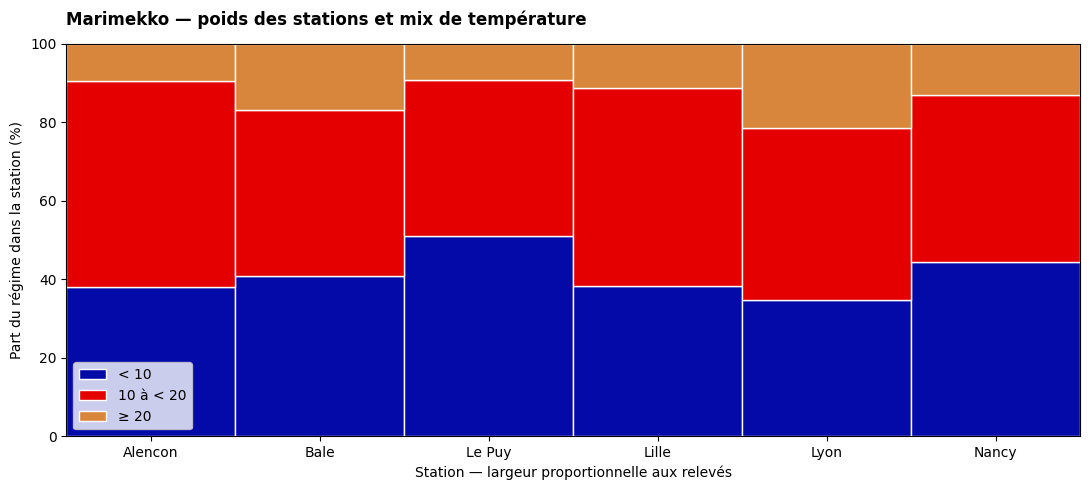

In [10]:
ID_GRAPHIQUE = '08_02'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes(False)
bas=np.zeros(len(parts))
for j,col in enumerate(parts):ax.bar(gauches,parts[col],width=largeurs,align='edge',bottom=bas,color=palette[j],edgecolor='white',label=col);bas+=parts[col].to_numpy()
ax.set_xticks(gauches+largeurs.to_numpy()/2,parts.index);ax.set(xlim=(0,100),ylim=(0,100));ax.legend()
terminer(ax,'Marimekko — poids des stations et mix de température','Station — largeur proportionnelle aux relevés','Part du régime dans la station (%)')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn — composition avec Matplotlib</div></b>

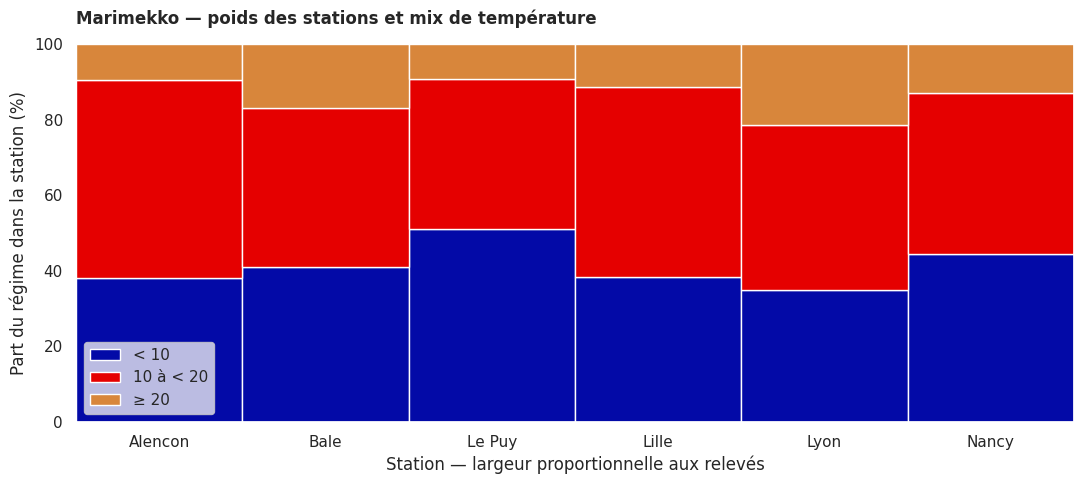

In [11]:
ID_GRAPHIQUE = '08_02'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
bas=np.zeros(len(parts))
for j,col in enumerate(parts):ax.bar(gauches,parts[col],width=largeurs,align='edge',bottom=bas,color=palette[j],edgecolor='white',label=col);bas+=parts[col].to_numpy()
ax.set_xticks(gauches+largeurs.to_numpy()/2,parts.index);ax.set(xlim=(0,100),ylim=(0,100));ax.legend()
terminer(ax,'Marimekko — poids des stations et mix de température','Station — largeur proportionnelle aux relevés','Part du régime dans la station (%)')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

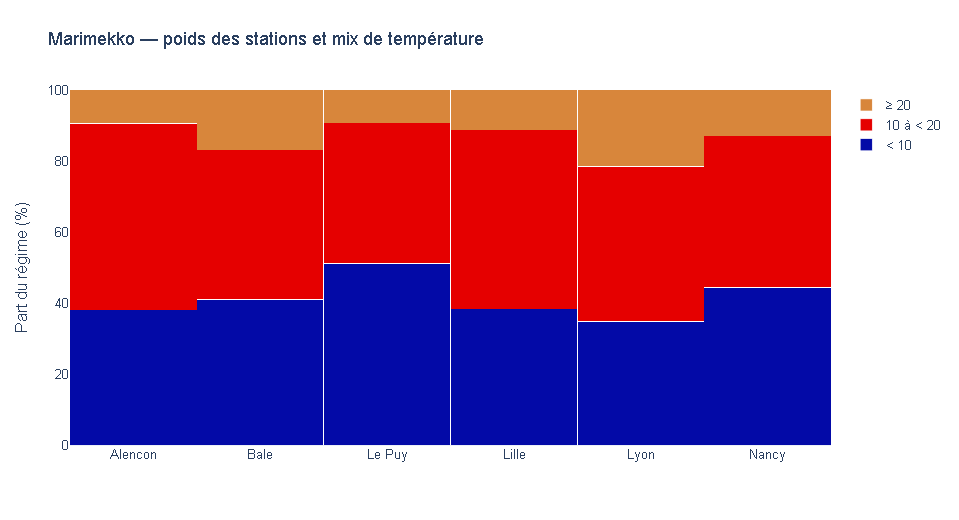

In [12]:
ID_GRAPHIQUE = '08_02'
BIBLIOTHEQUE = 'plotly'
fig=go.Figure()
for j,col in enumerate(parts):fig.add_trace(go.Bar(x=gauches+largeurs.to_numpy()/2,y=parts[col],width=largeurs,name=col,marker_color=palette[j],customdata=parts.index,hovertemplate='%{customdata} : %{y:.1f}%<extra></extra>'))
fig.update_layout(barmode='stack',bargap=0,xaxis={'tickvals':(gauches+largeurs.to_numpy()/2).tolist(),'ticktext':parts.index.tolist(),'range':[0,100]},yaxis={'range':[0,100],'title':'Part du régime (%)'})
montrer_plotly(fig,'Marimekko — poids des stations et mix de température')

**À lire dans les trois variantes :** Croiser poids des stations et composition thermique. Variables : station C + régime C + effectif Q. Largeur = part de station, hauteur = part du régime dans la station, aire = part de l’ensemble des relevés valides.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>3 — Gaufre de pourcentage</div></b>

Expliquer la part de relevés d’humidité au moins égale à 80 à la station principale. Variables : classe C + proportion Q. Une case = un point de pourcentage ; l’arrondi est explicite.

In [13]:
x=donnees.loc[donnees.Station.eq(station),'Humidite'].dropna()
SEUIL_HUMIDITE=80  # Seuil pédagogique dans l’unité source.
part=100*x.ge(SEUIL_HUMIDITE).mean();cases=int(np.floor(part+.5))
print(f'Station {station} : {len(x):,} relevés valides ; {part:.3f}% au moins à 80 ; {cases}/100 cases après arrondi.')

Station Alencon : 2,927 relevés valides ; 67.612% au moins à 80 ; 68/100 cases après arrondi.


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

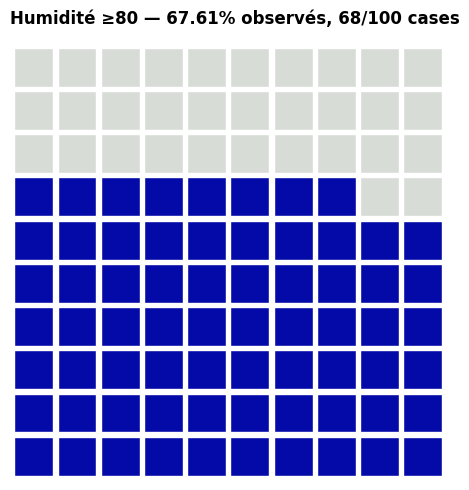

In [14]:
ID_GRAPHIQUE = '08_03'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes(False)
for i in range(100):ax.add_patch(Rectangle((i%10,i//10),.9,.9,facecolor=palette[0] if i<cases else '#d8dcd6',edgecolor='white'))
ax.set(xlim=(-.1,10),ylim=(-.1,10),aspect='equal');ax.axis('off')
terminer(ax,f'Humidité ≥80 — {part:.2f}% observés, {cases}/100 cases')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn — composition avec Matplotlib</div></b>

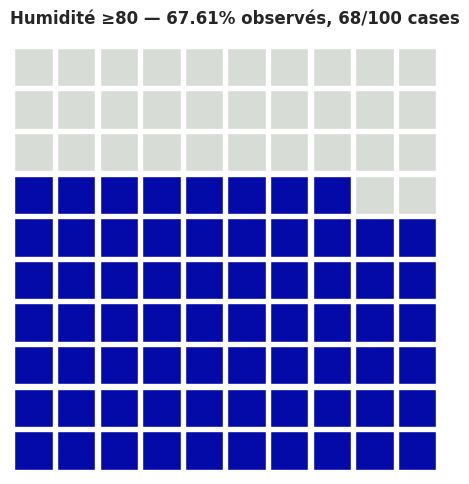

In [15]:
ID_GRAPHIQUE = '08_03'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
for i in range(100):ax.add_patch(Rectangle((i%10,i//10),.9,.9,facecolor=palette[0] if i<cases else '#d8dcd6',edgecolor='white'))
ax.set(xlim=(-.1,10),ylim=(-.1,10),aspect='equal');ax.axis('off')
terminer(ax,f'Humidité ≥80 — {part:.2f}% observés, {cases}/100 cases')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

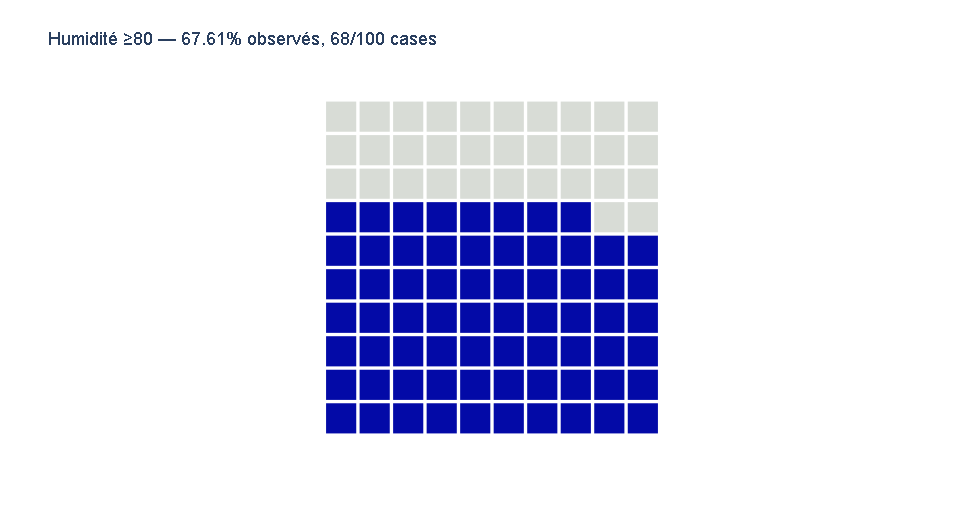

In [16]:
ID_GRAPHIQUE = '08_03'
BIBLIOTHEQUE = 'plotly'
fig=go.Figure()
for i in range(100):fig.add_shape(type='rect',x0=i%10,x1=i%10+.9,y0=i//10,y1=i//10+.9,fillcolor=palette[0] if i<cases else '#d8dcd6',line_width=0)
fig.update_xaxes(range=[-.1,10],visible=False);fig.update_yaxes(range=[-.1,10],visible=False,scaleanchor='x');montrer_plotly(fig,f'Humidité ≥80 — {part:.2f}% observés, {cases}/100 cases')

**À lire dans les trois variantes :** Expliquer la part de relevés d’humidité au moins égale à 80 à la station principale. Variables : classe C + proportion Q. Une case = un point de pourcentage ; l’arrondi est explicite.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>4 — Pyramide de distributions</div></b>

Comparer deux stations sur les mêmes classes de température. Variables : classe ordonnée O + station C + fréquence Q. Normaliser dans chaque station neutralise le nombre de relevés ; les valeurs négatives ne servent qu’au dessin.

In [17]:
deux=stations[:2];d=donnees.loc[donnees.Station.isin(deux)].dropna(subset=['Temperature']).copy()
bornes=np.r_[-np.inf,np.arange(-10,41,5),np.inf]
d['classe']=pd.cut(d.Temperature,bornes,right=False)
counts=pd.crosstab(d.classe,d.Station).reindex(columns=deux,fill_value=0)
a=counts.div(counts.sum(axis=0),axis=1)*100
labels=[str(v) for v in a.index];limite=float(a.max().max())*1.12
display(counts.sum().rename('n_releves'));display(a.round(2))

Station
Alencon    2927
Bale       2927
Name: n_releves, dtype: int64

Station,Alencon,Bale
classe,,
"[-10.0, -5.0)",0.00,0.38
"[-5.0, 0.0)",2.70,4.71
"[0.0, 5.0)",10.45,12.44
"[5.0, 10.0)",24.87,23.40
"[10.0, 15.0)",32.70,23.78
"[15.0, 20.0)",19.85,18.35
"[20.0, 25.0)",7.38,10.18
"[25.0, 30.0)",1.61,5.23
"[30.0, 35.0)",0.44,1.40


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

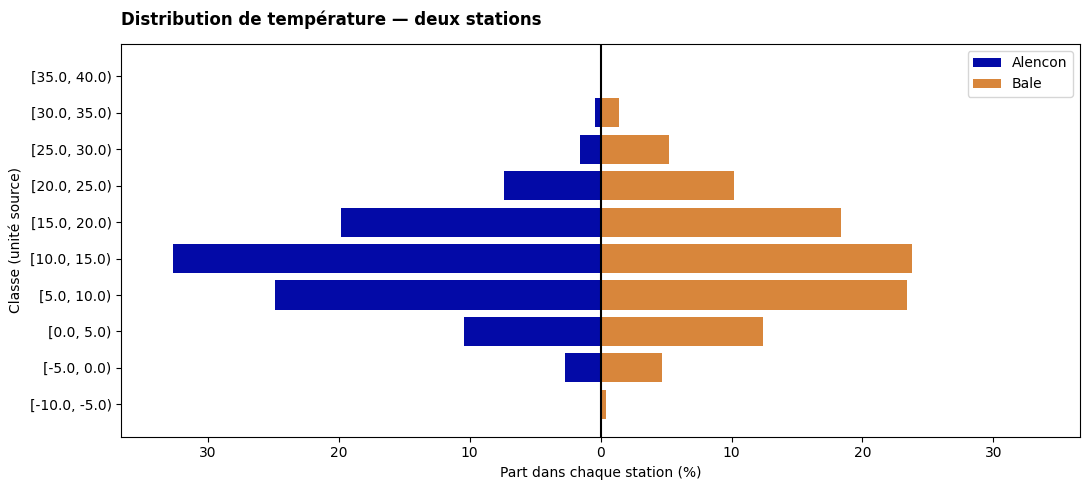

In [18]:
ID_GRAPHIQUE = '08_04'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
ax.barh(labels,-a[deux[0]],label=deux[0],color=palette[0]);ax.barh(labels,a[deux[1]],label=deux[1],color=palette[2]);ax.set_xlim(-limite,limite);ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,p:f'{abs(v):.0f}'));ax.axvline(0,color='black');ax.legend()
terminer(ax,'Distribution de température — deux stations','Part dans chaque station (%)','Classe (unité source)')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn — composition avec Matplotlib</div></b>

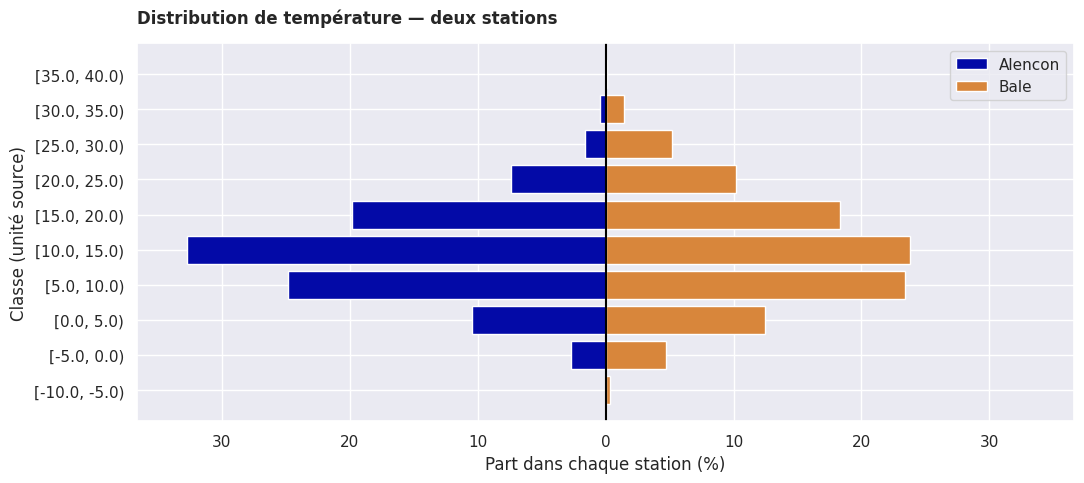

In [19]:
ID_GRAPHIQUE = '08_04'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
ax.barh(labels,-a[deux[0]],label=deux[0],color=sns.color_palette(palette)[0]);ax.barh(labels,a[deux[1]],label=deux[1],color=sns.color_palette(palette)[2]);ax.set_xlim(-limite,limite);ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,p:f'{abs(v):.0f}'));ax.axvline(0,color='black');ax.legend()
terminer(ax,'Distribution de température — deux stations','Part dans chaque station (%)','Classe (unité source)')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

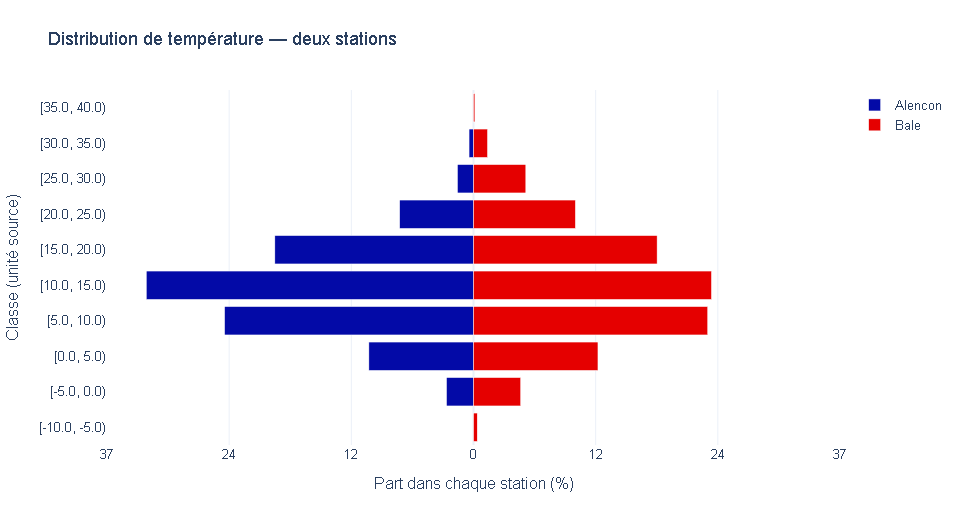

In [20]:
ID_GRAPHIQUE = '08_04'
BIBLIOTHEQUE = 'plotly'
fig=go.Figure([go.Bar(y=labels,x=-a[deux[0]],orientation='h',name=deux[0],customdata=a[deux[0]],hovertemplate='%{customdata:.2f}%<extra></extra>'),go.Bar(y=labels,x=a[deux[1]],orientation='h',name=deux[1],customdata=a[deux[1]],hovertemplate='%{customdata:.2f}%<extra></extra>')]);ticks=np.linspace(-limite,limite,7)
fig.update_layout(barmode='relative',xaxis={'range':[-limite,limite],'tickvals':ticks,'ticktext':[f'{abs(t):.0f}' for t in ticks],'title':'Part dans chaque station (%)'},yaxis_title='Classe (unité source)')
montrer_plotly(fig,'Distribution de température — deux stations')

**À lire dans les trois variantes :** Comparer deux stations sur les mêmes classes de température. Variables : classe ordonnée O + station C + fréquence Q. Normaliser dans chaque station neutralise le nombre de relevés ; les valeurs négatives ne servent qu’au dessin.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>5 — Nuage de points reliés</div></b>

Suivre le couple température–humidité mensuel de la même station. Variables : 2Q + mois ordonné. Les numéros indiquent la chronologie ; la trajectoire ne décrit pas une causalité.

In [21]:
d=donnees.loc[donnees.Station.eq(station)].dropna(subset=['Temperature','Humidite'])
a=d.groupby('mois')[['Temperature','Humidite']].mean().reindex(range(1,13)).reset_index()
display(a)

,mois,Temperature,Humidite
0,1,4.193145,85.959677
1,2,8.758874,87.515152
2,3,8.559677,83.286290
3,4,10.637083,77.420833
4,5,13.834677,80.516129
5,6,16.002083,74.329167
6,7,18.544355,74.991935
7,8,18.962500,75.633065
8,9,14.815833,82.525000
9,10,12.841129,89.370968


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

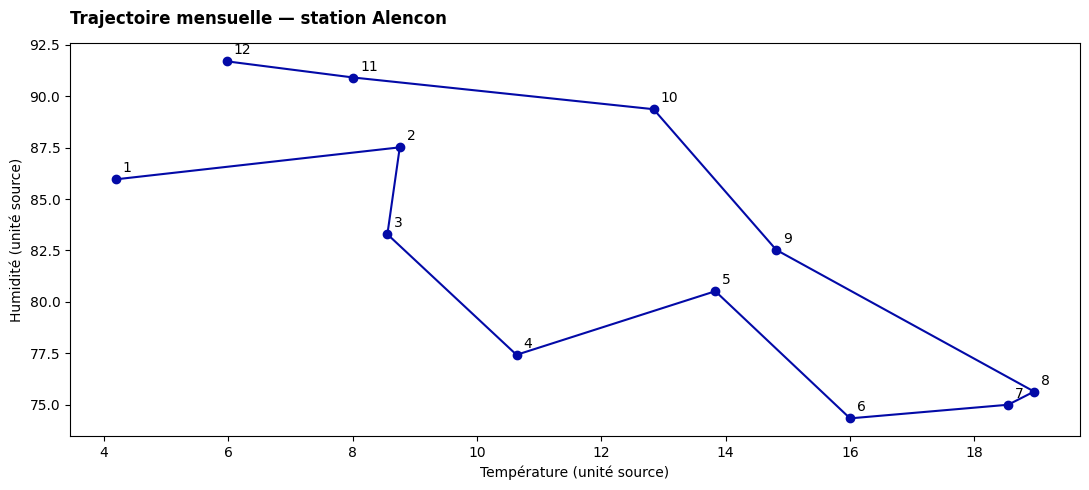

In [22]:
ID_GRAPHIQUE = '08_05'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
ax.plot(a.Temperature,a.Humidite,'o-',color=palette[0])
for r in a.dropna().itertuples():ax.annotate(str(r.mois),(r.Temperature,r.Humidite),xytext=(5,5),textcoords='offset points')
terminer(ax,f'Trajectoire mensuelle — station {station}','Température (unité source)','Humidité (unité source)')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn — composition avec Matplotlib</div></b>

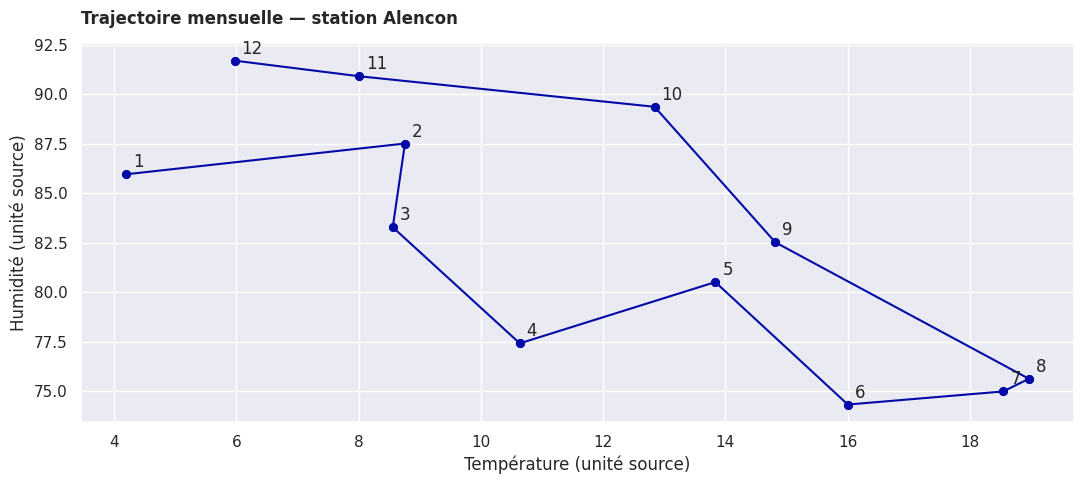

In [23]:
ID_GRAPHIQUE = '08_05'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
# sort=False préserve les mois ; sns.scatterplot ajoute les points sans retrier.
ax.plot(a.Temperature,a.Humidite,color=palette[0]);sns.scatterplot(data=a,x='Temperature',y='Humidite',s=55,color=palette[0],ax=ax)
for r in a.dropna().itertuples():ax.annotate(str(r.mois),(r.Temperature,r.Humidite),xytext=(5,5),textcoords='offset points')
terminer(ax,f'Trajectoire mensuelle — station {station}','Température (unité source)','Humidité (unité source)')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

In [24]:
ID_GRAPHIQUE = '08_05'
BIBLIOTHEQUE = 'plotly'
fig=go.Figure(go.Scatter(x=a.Temperature,y=a.Humidite,text=a.mois.astype(str),mode='lines+markers+text',textposition='top center',connectgaps=False))
fig.update_layout(xaxis_title='Température (unité source)',yaxis_title='Humidité (unité source)');montrer_plotly(fig,f'Trajectoire mensuelle — station {station}')

**À lire dans les trois variantes :** Suivre le couple température–humidité mensuel de la même station. Variables : 2Q + mois ordonné. Les numéros indiquent la chronologie ; la trajectoire ne décrit pas une causalité.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>6 — Aires empilées à 100 pour cent</div></b>

Suivre le mix mensuel des trois classes de température à la station principale. Variables : mois T + régime C + part Q. Le nombre de mesures reste dans la table ; des mois peu couverts ne deviennent pas fiables grâce à la normalisation.

In [25]:
d=donnees.loc[donnees.Station.eq(station) & donnees.regime.notna()]
regimes=['< 10','10 à < 20','≥ 20']
counts=pd.crosstab(d.mois,d.regime).reindex(index=range(1,13),columns=regimes,fill_value=0)
totaux=counts.sum(axis=1);a=100*counts.div(totaux.replace(0,np.nan),axis=0)
assert np.allclose(a.loc[totaux.gt(0)].sum(axis=1),100)
display(totaux.rename('n_releves'));display(a.round(2))

mois
1     248
2     231
3     248
4     240
5     248
6     240
7     248
8     248
9     240
10    248
11    240
12    248
Name: n_releves, dtype: int64

regime,< 10,10 à < 20,≥ 20
mois,,,
1,77.02,22.98,0.00
2,66.23,33.77,0.00
3,64.92,35.08,0.00
4,43.33,54.17,2.50
5,11.69,83.06,5.24
6,8.33,73.33,18.33
7,2.02,64.11,33.87
8,3.23,54.44,42.34
9,11.25,79.58,9.17


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

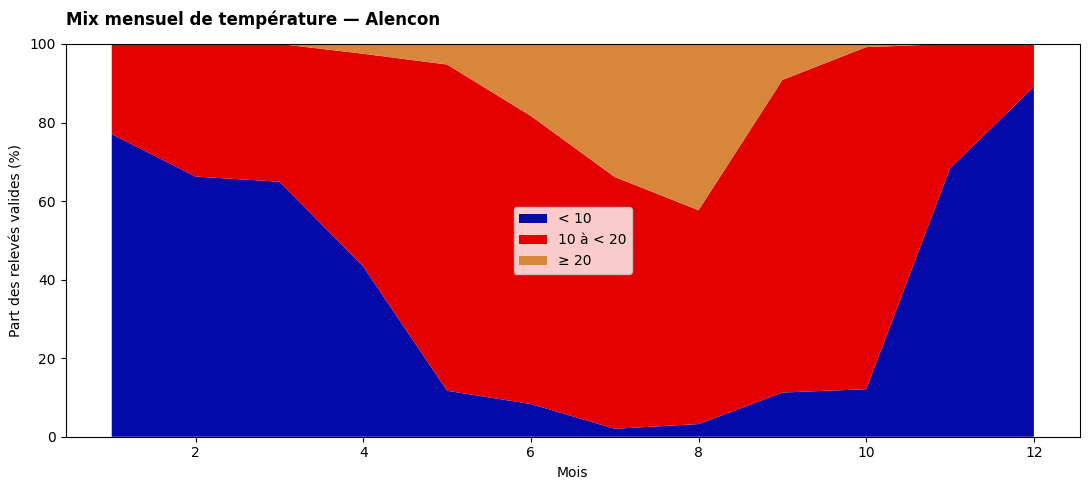

In [26]:
ID_GRAPHIQUE = '08_06'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
ax.stackplot(a.index,a.to_numpy().T,labels=regimes,colors=palette[:3]);ax.set_ylim(0,100);ax.legend()
terminer(ax,f'Mix mensuel de température — {station}','Mois','Part des relevés valides (%)')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn — composition avec Matplotlib</div></b>

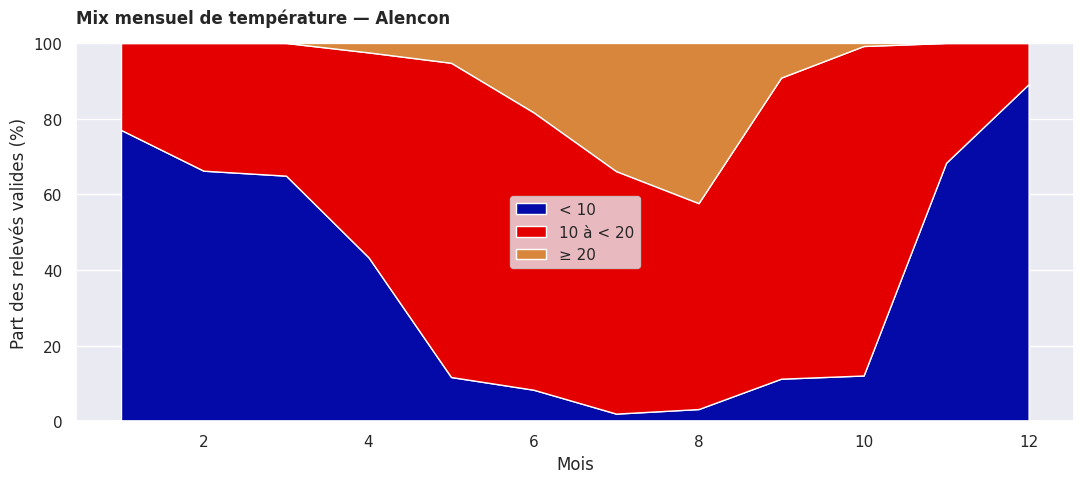

In [27]:
ID_GRAPHIQUE = '08_06'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
ax.stackplot(a.index,a.to_numpy().T,labels=regimes,colors=sns.color_palette(palette[:3]));ax.set_ylim(0,100);ax.legend()
terminer(ax,f'Mix mensuel de température — {station}','Mois','Part des relevés valides (%)')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

In [28]:
ID_GRAPHIQUE = '08_06'
BIBLIOTHEQUE = 'plotly'
long=a.rename_axis('mois').reset_index().melt(id_vars='mois',var_name='regime',value_name='part')
fig=px.area(long,x='mois',y='part',color='regime',category_orders={'regime':regimes},labels={'mois':'Mois','part':'Part des relevés valides (%)'});fig.update_yaxes(range=[0,100]);montrer_plotly(fig,f'Mix mensuel de température — {station}')

**À lire dans les trois variantes :** Suivre le mix mensuel des trois classes de température à la station principale. Variables : mois T + régime C + part Q. Le nombre de mesures reste dans la table ; des mois peu couverts ne deviennent pas fiables grâce à la normalisation.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Synthèse et exercices</div></b>

1. Reformuler la question métier de chacun des six graphiques.
2. Modifier un filtre ou une période et expliquer son effet sur le dénominateur.
3. Choisir une variante pour un rapport imprimé et une pour un tableau de bord interactif.
4. Vérifier l’unité, l’effectif, les valeurs manquantes et le sens des encodages.

**Limites :** Lecture de l’année 2024 uniquement, modifiable par ANNEE. Aucun dictionnaire d’unités n’est fourni : les valeurs sont compatibles avec °C, %, m/s et hPa, mais les axes conservent « unité source ». Les plages de contrôle sont des hypothèses exploratoires explicites, à valider avec le producteur. Les hors-plage sont masquées par variable et comptées, sans supprimer toute la ligne. Une moyenne entre stations n’est pas une moyenne climatique territoriale.